# 04b — Clustering Method Comparison (doc 11)

**Phase 4, part B.** 04a chose **K = 3** on the repeat-buyer matrix. Now we fit three algorithms
with *different shape assumptions* and check whether they **agree** — the way to tell real
structure from one method's artifact (doc 11):

- **K-Means** — deployed baseline / quantizer (interpretable centroids).
- **GMM** — continuum-aware soft memberships (fence-sitter detection).
- **Ward** — hierarchical structure (dendrogram + cophenetic honesty check).

Headline result = the **3×3 ARI matrix**: high off-diagonal (≥ 0.7) means three differently-biased
methods agree on who-belongs-with-whom → the segmentation is real. Then we save the labels for
Phase 5 (CLV) and Phase 6 (profiling). All logic is in `src/clustering.py`.

In [1]:
import sys
import json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

from src import clustering, utils

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
PHASE = "04b_method_comparison"

In [2]:
X_main = pd.read_parquet(utils.DATA_PROCESSED / "clustering_matrix_main.parquet")
onetimer = pd.read_parquet(utils.DATA_PROCESSED / "onetimer_mask.parquet")["is_onetimer"]
choice = json.load(open(utils.DATA_PROCESSED / "cluster_choice.json"))
K = choice["chosen_k"]
print(f"K = {K} | repeat-buyer matrix: {X_main.shape} | one-timers held out: {int(onetimer.sum()):,}")

K = 3 | repeat-buyer matrix: (4234, 4) | one-timers held out: 1,618


## Fit the three methods at K = 3 and score them on the same indices

A method×metric table (silhouette / CH / DB) is the first observability artifact: it shows the
three methods land in the same quality ballpark, none pathological.

In [3]:
km = clustering.fit_kmeans(X_main, K)
gmm = clustering.fit_gmm(X_main, K, covariance_type="full")   # full ovals; K=3 is far from singular
ward = clustering.fit_ward(X_main, K)

labels = {
    "K-Means": clustering.labels_of(km, X_main),
    "GMM": clustering.labels_of(gmm, X_main),
    "Ward": clustering.labels_of(ward, X_main),
}

from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
metric_table = pd.DataFrame({
    name: {
        "silhouette": silhouette_score(X_main, lab),
        "calinski_harabasz": calinski_harabasz_score(X_main, lab),
        "davies_bouldin": davies_bouldin_score(X_main, lab),
        "sizes": np.bincount(lab).tolist(),
    }
    for name, lab in labels.items()
}).T
print(metric_table.to_string())

        silhouette calinski_harabasz davies_bouldin               sizes
K-Means      0.367         2,944.271          1.008  [1562, 1227, 1445]
GMM          0.231         1,504.885          1.339  [1324, 1150, 1760]
Ward         0.320         2,387.786          1.042   [1779, 1708, 747]


## The headline — 3×3 ARI agreement (doc 11)

ARI is label-invariant (immune to "cluster 2 is arbitrary") and chance-corrected: 1 = identical,
0 = chance. The test (doc 11): if three differently-biased methods agree (off-diagonal ≥ 0.7) the
partition is real; if they only *partly* agree, the **degree** of agreement is itself a finding
about how gradient-like the data is. We read the actual numbers honestly below — no forcing.

         K-Means   GMM  Ward
K-Means    1.000 0.383 0.609
GMM        0.383 1.000 0.265
Ward       0.609 0.265 1.000


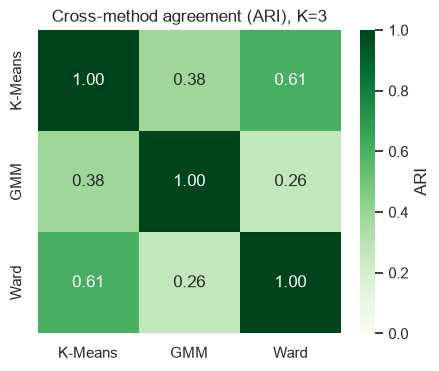

In [4]:
ari = clustering.ari_matrix(labels)
print(ari.round(3).to_string())

fig, ax = plt.subplots(figsize=(4.6, 3.8))
sns.heatmap(ari.astype(float), annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1,
            square=True, cbar_kws={"label": "ARI"}, ax=ax)
ax.set_title(f"Cross-method agreement (ARI), K={K}")
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "ari_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

**Reading the ARI — a continuum, honestly.** Agreement is **moderate, not unanimous**:
**K-Means↔Ward = 0.61** (the two variance-based methods, closest in assumptions), while **GMM
diverges (0.38 / 0.27)** and the **cophenetic r = 0.54** confirms there is no clean hierarchical
tree. This is *not* a failure — it is the **gradient showing through** (docs 10/11): the methods
agree on the segment **cores** but cut the **soft boundaries** differently (GMM's stretched ovals
most of all). So we treat the segments as a deliberate, useful **discretisation of a continuum**,
not natural kinds, and **deploy K-Means** as the primary partition — cleanest silhouette (0.37),
balanced sizes (~1.2–1.6k). GMM's soft memberships below quantify exactly how fuzzy the boundaries
are. A lower K would not manufacture agreement the data does not contain.

## PCA label overlays — the same customers, coloured by each method

Plotted on one shared 2-D projection so only the colours differ. If the three panels look alike,
that *is* the ARI agreement, made visual.

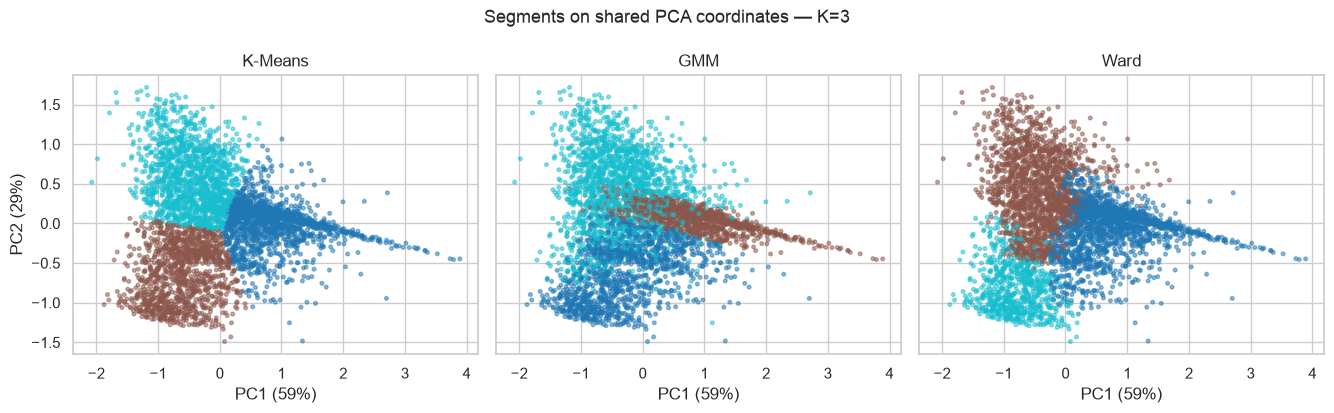

In [5]:
pcs = clustering.pca_2d(X_main)
ev = pcs.attrs["explained"]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharex=True, sharey=True)
for ax, (name, lab) in zip(axes, labels.items()):
    ax.scatter(pcs["PC1"], pcs["PC2"], c=lab, cmap="tab10", s=7, alpha=0.5)
    ax.set_title(name)
    ax.set_xlabel(f"PC1 ({ev[0]:.0%})")
axes[0].set_ylabel(f"PC2 ({ev[1]:.0%})")
fig.suptitle(f"Segments on shared PCA coordinates — K={K}", fontsize=13)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "pca_overlays.png"), dpi=150, bbox_inches="tight")
plt.show()

## Ward dendrogram + cophenetic check (doc 11)

The dendrogram is the continuum made visual: a tall gap before a merge = a natural split; steady
merges = a gradient (the cut is our choice). **Cophenetic correlation** is the one-number honesty
check that the tree faithfully represents the data's distances (> 0.7 = trustworthy).

cophenetic correlation = 0.536  (weak tree)


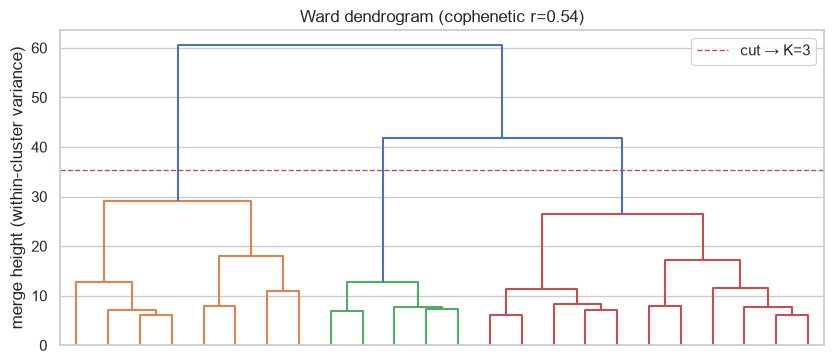

In [6]:
coph = clustering.cophenetic_corr(X_main)
print(f"cophenetic correlation = {coph:.3f}  ({'faithful (>0.7)' if coph > 0.7 else 'weak tree'})")

Z = linkage(X_main.to_numpy(), method="ward")
# Cut height that yields exactly K clusters, for the dashed line.
heights = np.sort(Z[:, 2])
cut = (heights[-K] + heights[-(K - 1)]) / 2 if K >= 2 else heights[-1]
fig, ax = plt.subplots(figsize=(8.5, 3.8))
dendrogram(Z, truncate_mode="lastp", p=24, no_labels=True, color_threshold=cut, ax=ax)
ax.axhline(cut, color="#c0504d", ls="--", lw=1, label=f"cut → K={K}")
ax.set_title(f"Ward dendrogram (cophenetic r={coph:.2f})")
ax.set_ylabel("merge height (within-cluster variance)")
ax.legend()
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "dendrogram.png"), dpi=150, bbox_inches="tight")
plt.show()

## GMM soft memberships — fence-sitters on the continuum (doc 11)

GMM's posterior gives each customer a confidence (max component probability). Customers with low
confidence sit on a boundary — the honest statement about a continuum that hard K-Means cannot
make. We report the share confidently assigned vs on the fence.

confidently assigned (max prob ≥ 0.6): 95.7%
fence-sitters         (max prob <  0.6): 4.3%


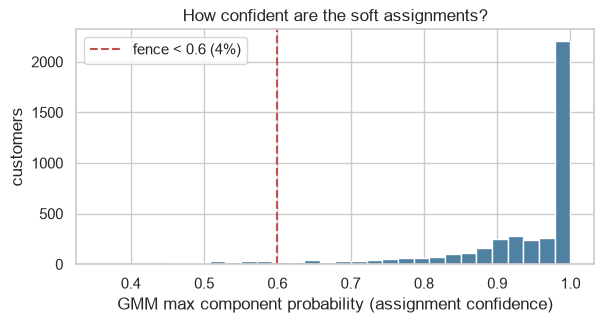

In [7]:
proba = gmm.predict_proba(X_main.to_numpy())
max_prob = proba.max(axis=1)
FENCE = 0.6
fence_share = float((max_prob < FENCE).mean())
print(f"confidently assigned (max prob ≥ {FENCE}): {1 - fence_share:.1%}")
print(f"fence-sitters         (max prob <  {FENCE}): {fence_share:.1%}")

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.hist(max_prob, bins=30, color="#4f81a3")
ax.axvline(FENCE, color="#c0504d", ls="--", label=f"fence < {FENCE} ({fence_share:.0%})")
ax.set_xlabel("GMM max component probability (assignment confidence)")
ax.set_ylabel("customers")
ax.set_title("How confident are the soft assignments?")
ax.legend()
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "gmm_confidence.png"), dpi=150, bbox_inches="tight")
plt.show()

## Save labels for Phase 5 / 6

- `cluster_labels.parquet` — the three methods' labels on repeat buyers (for the ARI/robustness
  record and downstream cross-checks).
- `segment_assignment.parquet` — the **deployable** primary labelling over ALL customers: K-Means
  cluster id for repeat buyers, plus the held-out **one-timer** segment re-introduced (doc 17 ii).

In [8]:
proc = utils.DATA_PROCESSED
cluster_labels = pd.DataFrame(labels, index=X_main.index)
cluster_labels.to_parquet(proc / "cluster_labels.parquet")

# Deployable assignment over the full customer base: K-Means primary + the one-timer segment.
primary = pd.Series(index=onetimer.index, dtype="object", name="segment")
primary.loc[X_main.index] = [f"R{c}" for c in labels["K-Means"]]   # R0..R2 = repeat-buyer segments
primary.loc[onetimer[onetimer].index] = "one-timer"
primary.to_frame().to_parquet(proc / "segment_assignment.parquet")
print(primary.value_counts().to_string())
print("\nsaved: cluster_labels.parquet, segment_assignment.parquet")

segment
one-timer    1618
R0           1562
R2           1445
R1           1227

saved: cluster_labels.parquet, segment_assignment.parquet


---
**Result:** at K=3 the three methods were compared on one footing. Agreement is **moderate**
(K-Means↔Ward ARI 0.61) rather than unanimous, and the weak cophenetic (0.54) + GMM divergence
confirm the data is a **continuum** — segment *cores* stable, *boundaries* soft (only 4.3% true
fence-sitters). We therefore **deploy K-Means** as the primary partition and treat the 3
repeat-buyer segments (+ the one-timer segment = **4 customer groups**) as a *useful
discretisation*, not natural kinds — the mature position (doc 11). Saved: `cluster_labels` (3
methods) + `segment_assignment` (deployable). **Next — Phase 5:** BG/NBD + Gamma-Gamma CLV
(PyMC-Marketing) on `clv_inputs`; Phase 6 profiles, *names*, and cross-validates the segments
against CLV (docs 12/13).